# ZOIDBERG2.0 - Step 4: Deep Learning CNN Implementation

**Project:** Medical Imaging / Computer Aided Diagnosis - Pneumonia Detection  
**Author:** Deep Learning Architecture Team  
**Date:** January 2026  


---

## Objectives

1. **Custom CNN Architecture:**
   - Design and implement custom CNN for pneumonia detection
   - Optimize architecture for medical imaging

2. **Transfer Learning:**
   - VGG16 (pre-trained on ImageNet)
   - ResNet50 (pre-trained on ImageNet)
   - Fine-tuning strategies

3. **Training Strategy:**
   - Train-validation split (80/20)
   - Early stopping and learning rate scheduling
   - Data augmentation

4. **Hyperparameter Tuning:**
   - Use Dataset3 as validation set
   - Optimize learning rate, batch size, epochs

5. **Evaluation:**
   - Compare deep learning vs baseline models
   - ROC-AUC analysis
   - Confusion matrices and learning curves

6. **Bonus - 3-Class Classification:**
   - Extend to NORMAL/VIRUS/BACTERIA classification
   - Multi-class ROC-AUC evaluation

---

In [9]:
# Import Required Libraries
import os
import sys
print(sys.executable)

import sys
import warnings
from pathlib import Path
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import yaml

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

# Torchvision for pre-trained models
import torchvision.models as models
import torchvision.transforms as transforms

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder

import joblib

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Add src to path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root / 'src'))

# Import custom modules
from utils.helpers import set_seed, Logger

print("✓ Libraries imported successfully")
print(f"✓ Project root: {project_root}")
print(f"✓ PyTorch version: {torch.__version__}")

/Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19/.venv/bin/python
Using device: cpu
✓ Libraries imported successfully
✓ Project root: /Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19
✓ PyTorch version: 2.12.1


In [10]:
# Load Configuration
config_path = project_root / 'config' / 'config.yaml'

with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Set random seed for reproducibility
set_seed(config['reproducibility']['seed'])

# Set PyTorch seeds
torch.manual_seed(config['reproducibility']['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(config['reproducibility']['seed'])
    torch.cuda.manual_seed_all(config['reproducibility']['seed'])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("✓ Configuration loaded")
print(f"\nProject: {config['project']['name']} v{config['project']['version']}")
print(f"Random Seed: {config['reproducibility']['seed']}")
print(f"Batch Size: {config['deep_learning']['batch_size']}")
print(f"Epochs: {config['deep_learning']['epochs']}")

✓ Random seed set to 42
✓ Configuration loaded

Project: ZOIDBERG2.0 v2.0.0
Random Seed: 42
Batch Size: 32
Epochs: 50


In [11]:
# Initialize Logger
log_path = project_root / config['logging']['log_file']
logger = Logger(log_path)

logger.info("="*60)
logger.info("STEP 4: DEEP LEARNING CNN IMPLEMENTATION")
logger.info("="*60)

[INFO] ============================================================
[INFO] STEP 4: DEEP LEARNING CNN IMPLEMENTATION
[INFO] ============================================================


---
## 1. Load and Prepare Data

Load preprocessed data and reshape for CNN input (add channel dimension).

In [12]:
# Load preprocessed data - Need FULL IMAGES for CNN, not PCA features
processed_dir = project_root / 'data' / 'processed'

print("Loading data for CNN training...\n")
print("⚠️  NOTE: CNNs require full images, not PCA-reduced features")
print("    Loading original image paths and preprocessing on-the-fly\n")

# Load preprocessing metadata
with open(processed_dir / 'preprocessing_metadata.json', 'r', encoding='utf-8') as f:
    preprocessing_meta = json.load(f)

target_size = tuple(preprocessing_meta['target_size'])
print(f"Target image size: {target_size}")

# ============================================================
# LABELS 3 CLASSES : NORMAL / VIRUS / BACTERIA
# Le type de pneumonie (virus/bacterie) est dans le NOM du fichier,
# pas dans le dossier -> on l'extrait ici.
# ============================================================
data_raw = project_root / 'data' / 'raw'

def get_label_3class(folder, filename):
    if folder == 'NORMAL':
        return 'NORMAL'
    f = filename.lower()
    if 'bacteria' in f:
        return 'BACTERIA'
    if 'virus' in f:
        return 'VIRUS'
    return 'UNKNOWN'  # ne doit jamais apparaitre

all_image_paths = []
all_labels = []
for dataset_name in ['dataset1', 'dataset2']:
    for folder in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_raw / dataset_name / folder
        if class_dir.exists():
            files = list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
            for fpath in files:
                all_image_paths.append(str(fpath))
                all_labels.append(get_label_3class(folder, fpath.name))

all_image_paths = np.array(all_image_paths)
all_labels_str = np.array(all_labels)

# Verif : aucune image non classee
n_unknown = int((all_labels_str == 'UNKNOWN').sum())
if n_unknown > 0:
    print(f"WARNING: {n_unknown} images non classees (ni 'virus' ni 'bacteria' dans le nom de fichier)")

# Encodage 3 classes (NOUVEL encodeur, on n'utilise plus l'encodeur binaire)
from sklearn.preprocessing import LabelEncoder
label_encoder_3 = LabelEncoder()
all_labels = label_encoder_3.fit_transform(all_labels_str)
class_names = list(label_encoder_3.classes_)            # ex : ['BACTERIA', 'NORMAL', 'VIRUS']
num_classes = len(class_names)
label_mapping = {name: int(i) for i, name in enumerate(class_names)}

# Sauvegarde du nouvel encodeur (utile pour l'inference)
encoder_3_path = project_root / 'models' / 'saved_models' / 'label_encoder_3class.pkl'
encoder_3_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(label_encoder_3, encoder_3_path)

print(f"\nTotal images found: {len(all_image_paths)}")
print(f"Classes ({num_classes}) : {label_mapping}")
print(f"Distribution globale : {dict(zip(class_names, np.bincount(all_labels, minlength=num_classes)))}")

# ============================================================
# SPLIT PAR PATIENT (anti-fuite de donnees)
# Un meme patient possede souvent plusieurs radios : il ne doit
# JAMAIS se retrouver a la fois dans train et dans test, sinon le
# modele "reconnait le patient" et les scores sont artificiellement gonfles.
# L'identifiant patient est dans le nom de fichier (ex: person53_bacteria_2.jpeg).
# ============================================================
import re
from sklearn.model_selection import GroupShuffleSplit

def get_patient_id(path):
    stem = Path(path).stem
    m = re.match(r'(person\d+)', stem)      # pneumonie : personXX_bacteria/virus_YY
    if m:
        return m.group(1)
    m = re.match(r'(.+)-\d+$', stem)         # normal : IM-0115-0001 -> IM-0115
    if m:
        return m.group(1)
    return stem                              # fallback : image isolee

groups = np.array([get_patient_id(p) for p in all_image_paths])

# Split 1 : (train+val) / test, par patient
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2,
                             random_state=config['reproducibility']['seed'])
trainval_idx, test_idx = next(gss_test.split(all_image_paths, all_labels, groups))

X_train_paths   = all_image_paths[trainval_idx]
X_test_paths    = all_image_paths[test_idx]
y_train_full    = all_labels[trainval_idx]
y_test_full     = all_labels[test_idx]
groups_trainval = groups[trainval_idx]

# Split 2 : train / val, par patient
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25,
                            random_state=config['reproducibility']['seed'])
train_idx, val_idx = next(gss_val.split(X_train_paths, y_train_full, groups_trainval))

X_train_paths_split = X_train_paths[train_idx]
X_val_paths_split   = X_train_paths[val_idx]
y_train_split       = y_train_full[train_idx]
y_val_split         = y_train_full[val_idx]

# Verification anti-fuite : 0 patient commun entre les sets
s_train = set(groups_trainval[train_idx])
s_val   = set(groups_trainval[val_idx])
s_test  = set(groups[test_idx])
print(f"\nData Split (par patient) :")
print(f"  Train: {len(X_train_paths_split)} images / {len(s_train)} patients")
print(f"  Val:   {len(X_val_paths_split)} images / {len(s_val)} patients")
print(f"  Test:  {len(X_test_paths)} images / {len(s_test)} patients")
print(f"  Patients communs train/test : {len(s_train & s_test)}  (doit = 0)")
print(f"  Patients communs val/test   : {len(s_val & s_test)}  (doit = 0)")
print(f"  Patients communs train/val  : {len(s_train & s_val)}  (doit = 0)")
print(f"\nDistribution par set :")
print(f"  Train: {dict(zip(class_names, np.bincount(y_train_split, minlength=num_classes)))}")
print(f"  Val:   {dict(zip(class_names, np.bincount(y_val_split, minlength=num_classes)))}")
print(f"  Test:  {dict(zip(class_names, np.bincount(y_test_full, minlength=num_classes)))}")


# Load and preprocess images with proper normalization
import cv2
from scipy import ndimage

def compute_dataset_statistics(image_paths, target_size=(224, 224), sample_size=1000):
    """Compute mean and std from a sample of images for normalization."""
    sample_paths = np.random.choice(image_paths, min(sample_size, len(image_paths)), replace=False)
    pixel_values = []
    
    for img_path in tqdm(sample_paths, desc="Computing dataset statistics"):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, target_size)
            pixel_values.append(img.flatten())
    
    all_pixels = np.concatenate(pixel_values)
    mean = all_pixels.mean() / 255.0
    std = all_pixels.std() / 255.0
    return mean, std

def load_and_preprocess_images(image_paths, target_size=(224, 224), mean=None, std=None, augment=False):
    """Load and preprocess images with consistent normalization and optional augmentation."""
    images = []
    
    print(f"Loading {len(image_paths)} images (augment={augment})...")
    for img_path in tqdm(image_paths, desc="Loading images"):
        # Read image
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        
        if img is None:
            print(f"Warning: Failed to load {img_path}")
            continue
        
        # Resize
        img = cv2.resize(img, target_size)
        
        # Data augmentation for training only
        if augment:
            # Random rotation (-10 to 10 degrees)
            if np.random.rand() > 0.5:
                angle = np.random.uniform(-10, 10)
                img = ndimage.rotate(img, angle, reshape=False, mode='nearest')
            
            # Random horizontal flip
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 1)
            
            # Random brightness adjustment
            if np.random.rand() > 0.5:
                factor = np.random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)
        
        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0
        
        # Standardize using dataset statistics
        if mean is not None and std is not None:
            img = (img - mean) / (std + 1e-7)
        
        # Add channel dimension (1, H, W)
        img = np.expand_dims(img, axis=0)
        
        images.append(img)
    
    return np.array(images)

# Compute dataset statistics from training set
print("\nComputing dataset normalization statistics...")
dataset_mean, dataset_std = compute_dataset_statistics(X_train_paths_split, target_size)
print(f"Dataset statistics: mean={dataset_mean:.4f}, std={dataset_std:.4f}")

# Load images with consistent normalization
print("\nLoading training images (with augmentation)...")
X_train_cnn = load_and_preprocess_images(X_train_paths_split, target_size, 
                                         mean=dataset_mean, std=dataset_std, augment=True)

print("\nLoading validation images (no augmentation)...")
X_val_cnn = load_and_preprocess_images(X_val_paths_split, target_size,
                                       mean=dataset_mean, std=dataset_std, augment=False)

print("\nLoading test images (no augmentation)...")
X_test_cnn = load_and_preprocess_images(X_test_paths, target_size,
                                        mean=dataset_mean, std=dataset_std, augment=False)

print(f"\nFinal shapes:")
print(f"  X_train: {X_train_cnn.shape} (N, C, H, W)")
print(f"  X_val:   {X_val_cnn.shape}")
print(f"  X_test:  {X_test_cnn.shape}")
print(f"  y_train: {y_train_split.shape}")
print(f"  y_val:   {y_val_split.shape}")
print(f"  y_test:  {y_test_full.shape}")

logger.info(f"Data loaded: Train={X_train_cnn.shape}, Val={X_val_cnn.shape}, Test={X_test_cnn.shape}")

Loading data for CNN training...

⚠️  NOTE: CNNs require full images, not PCA-reduced features
    Loading original image paths and preprocessing on-the-fly

Target image size: (224, 224)

Total images found: 5232
Classes (3) : {np.str_('BACTERIA'): 0, np.str_('NORMAL'): 1, np.str_('VIRUS'): 2}
Distribution globale : {np.str_('BACTERIA'): np.int64(2538), np.str_('NORMAL'): np.int64(1349), np.str_('VIRUS'): np.int64(1345)}

Data Split (par patient) :
  Train: 3150 images / 1756 patients
  Val:   1045 images / 586 patients
  Test:  1037 images / 586 patients
  Patients communs train/test : 0  (doit = 0)
  Patients communs val/test   : 0  (doit = 0)
  Patients communs train/val  : 0  (doit = 0)

Distribution par set :
  Train: {np.str_('BACTERIA'): np.int64(1535), np.str_('NORMAL'): np.int64(807), np.str_('VIRUS'): np.int64(808)}
  Val:   {np.str_('BACTERIA'): np.int64(490), np.str_('NORMAL'): np.int64(268), np.str_('VIRUS'): np.int64(287)}
  Test:  {np.str_('BACTERIA'): np.int64(513), np

Computing dataset statistics: 100%|█████████████████████████████████| 1000/1000 [00:02<00:00, 364.06it/s]


Dataset statistics: mean=0.4819, std=0.2389

Loading training images (with augmentation)...
Loading 3150 images (augment=True)...


Loading images: 100%|███████████████████████████████████████████████| 3150/3150 [00:12<00:00, 258.52it/s]



Loading validation images (no augmentation)...
Loading 1045 images (augment=False)...


Loading images: 100%|███████████████████████████████████████████████| 1045/1045 [00:02<00:00, 363.52it/s]



Loading test images (no augmentation)...
Loading 1037 images (augment=False)...


Loading images: 100%|███████████████████████████████████████████████| 1037/1037 [00:02<00:00, 357.07it/s]



Final shapes:
  X_train: (3150, 1, 224, 224) (N, C, H, W)
  X_val:   (1045, 1, 224, 224)
  X_test:  (1037, 1, 224, 224)
  y_train: (3150,)
  y_val:   (1045,)
  y_test:  (1037,)
[INFO] Data loaded: Train=(3150, 1, 224, 224), Val=(1045, 1, 224, 224), Test=(1037, 1, 224, 224)


In [13]:
# Convert to PyTorch tensors and create DataLoaders
batch_size = config['deep_learning']['batch_size']

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_cnn)
y_train_tensor = torch.LongTensor(y_train_split)

X_val_tensor = torch.FloatTensor(X_val_cnn)
y_val_tensor = torch.LongTensor(y_val_split)

X_test_tensor = torch.FloatTensor(X_test_cnn)
y_test_tensor = torch.LongTensor(y_test_full)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✓ DataLoaders created")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

✓ DataLoaders created
  Batch size: 32
  Train batches: 99
  Val batches:   33
  Test batches:  33


---
## 2. Custom CNN Architecture

Design a custom CNN optimized for pneumonia detection.

In [14]:
class PneumoniaCNN(nn.Module):
    """
    Custom CNN architecture for pneumonia detection.
    
    Architecture:
    - 3 convolutional blocks with batch normalization and dropout
    - MaxPooling for spatial dimension reduction
    - Fully connected layers with dropout
    - Binary classification output
    
    Improvements:
    - BatchNorm with momentum=0.01 for stability with small batches
    - Reduced dropout for better learning
    - Layer normalization option for stability
    """
    
    def __init__(self, input_channels=1, num_classes=2, dropout_rate=0.3):
        super(PneumoniaCNN, self).__init__()
        
        # Convolutional Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32, momentum=0.01, eps=1e-3),  # More stable BatchNorm
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate * 0.5)
        )
        
        # Convolutional Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate * 0.5)
        )
        
        # Convolutional Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate * 0.5)
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully Connected Layers with reduced dropout
        self.fc = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128, momentum=0.01, eps=1e-3),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x


# Create model instance with reduced dropout for better learning
custom_cnn = PneumoniaCNN(input_channels=1, num_classes=num_classes, dropout_rate=0.3).to(device)

# Print model architecture
print("\n" + "="*60)
print("CUSTOM CNN ARCHITECTURE")
print("="*60)
print(custom_cnn)

# Count parameters
total_params = sum(p.numel() for p in custom_cnn.parameters())
trainable_params = sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

logger.info(f"Custom CNN created: {trainable_params:,} trainable parameters")


CUSTOM CNN ARCHITECTURE
PneumoniaCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.15, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True

---
## 3. Training Utilities

Define training and evaluation functions.

In [15]:
def train_epoch(model, train_loader, criterion, optimizer, device, gradient_clip=1.0):
    """
    Train model for one epoch with gradient clipping.
    
    Returns:
        float: Average training loss
        float: Training accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


def evaluate_model(model, data_loader, criterion, device):
    """
    Evaluate model on validation/test set.
    
    Returns:
        float: Average loss
        float: Accuracy
        np.ndarray: True labels
        np.ndarray: Predicted labels
        np.ndarray: Prediction probabilities
    """
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []
    all_probabilities = []
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            
            # Get predictions
            probabilities = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())  # Matrice de proba complete (N, num_classes)
    
    avg_loss = running_loss / len(data_loader.dataset)
    accuracy = 100 * accuracy_score(all_labels, all_predictions)
    
    return avg_loss, accuracy, np.array(all_labels), np.array(all_predictions), np.array(all_probabilities)


def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs, device, early_stopping_patience=10, model_name='model', warmup_epochs=3):
    """
    Full training loop with early stopping, warmup, and enhanced monitoring.
    
    Returns:
        dict: Training history
    """
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rates': []
    }
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    initial_lr = optimizer.param_groups[0]['lr']
    
    print(f"\nTraining {model_name}...")
    print("="*60)
    print(f"Configuration:")
    print(f"  - Training samples: {len(train_loader.dataset)}")
    print(f"  - Validation samples: {len(val_loader.dataset)}")
    print(f"  - Batch size: {train_loader.batch_size}")
    print(f"  - Initial LR: {initial_lr:.6f}")
    print(f"  - Warmup epochs: {warmup_epochs}")
    print(f"  - Early stopping patience: {early_stopping_patience}")
    print("="*60)
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Learning rate warmup for first few epochs
        if epoch < warmup_epochs:
            warmup_lr = initial_lr * (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = warmup_lr
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, gradient_clip=1.0)
        
        # Validate
        val_loss, val_acc, _, _, _ = evaluate_model(model, val_loader, criterion, device)
        
        # Learning rate scheduling (after warmup)
        if epoch >= warmup_epochs and scheduler is not None:
            scheduler.step(val_loss)
        
        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['learning_rates'].append(optimizer.param_groups[0]['lr'])
        
        epoch_time = time.time() - start_time
        
        # Calculate loss/acc differences for monitoring
        loss_diff = abs(val_loss - train_loss)
        acc_diff = val_acc - train_acc
        
        # Print progress with enhanced monitoring
        print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.1f}s) - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Warning for suspicious behavior
        if loss_diff > 0.5:
            print(f"  ⚠️  Large train-val loss gap ({loss_diff:.4f}) - possible overfitting")
        if acc_diff > 10:
            print(f"  ⚠️  Val acc >> train acc ({acc_diff:+.2f}%) - check data preprocessing")
        if val_loss > 2.0:
            print(f"  ⚠️  High validation loss - model may be unstable")
        
        # Early stopping check - use val_loss as primary metric
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"  ✓ New best model (Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"\n⚠️  Early stopping triggered (patience: {early_stopping_patience})")
                break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n✓ Restored best model (Val Loss: {best_val_loss:.4f}, Val Acc: {best_val_acc:.2f}%)")
    
    return history

print("✓ Training utilities defined")

✓ Training utilities defined


---
## 4. Train Custom CNN

Train the custom CNN architecture.

In [16]:
# Training configuration - reduced LR for stability
num_epochs = config['deep_learning']['epochs']
learning_rate = config['deep_learning']['learning_rate'] * 0.3  # Reduced from 0.001 to 0.0003
weight_decay = 1e-4

# Loss function (with balanced class weights)
class_counts = np.bincount(y_train_split, minlength=num_classes)
total_samples = len(y_train_split)
# Compute balanced weights: n_samples / (n_classes * class_count)
class_weights = torch.FloatTensor([
    total_samples / (len(class_counts) * count) for count in class_counts
]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with better defaults
optimizer = optim.AdamW(custom_cnn.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(0.9, 0.999))

# Learning rate scheduler - more aggressive
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

print(f"Training Configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning Rate: {learning_rate}")
print(f"  Weight Decay: {weight_decay}")
print(f"  Class Weights: {class_weights.cpu().numpy()}")
print(f"  Early Stopping Patience: 10")

logger.info(f"Training Custom CNN: lr={learning_rate}, epochs={num_epochs}")

# Train model
custom_cnn_history = train_model(
    model=custom_cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    early_stopping_patience=10,
    model_name='Custom CNN'
)

print("\n✓ Custom CNN training complete")

Training Configuration:
  Epochs: 50
  Learning Rate: 8.999999999999999e-05
  Weight Decay: 0.0001
  Class Weights: [0.6840391 1.3011153 1.299505 ]
  Early Stopping Patience: 10
[INFO] Training Custom CNN: lr=8.999999999999999e-05, epochs=50

Training Custom CNN...
Configuration:
  - Training samples: 3150
  - Validation samples: 1045
  - Batch size: 32
  - Initial LR: 0.000090
  - Warmup epochs: 3
  - Early stopping patience: 10


Epoch [1/50] (250.8s) - Train Loss: 1.0634, Train Acc: 38.35% | Val Loss: 1.0866, Val Acc: 27.46% | LR: 0.000030
  ✓ New best model (Val Loss: 1.0866, Val Acc: 27.46%)


Epoch [2/50] (308.6s) - Train Loss: 0.9645, Train Acc: 50.29% | Val Loss: 1.1188, Val Acc: 46.89% | LR: 0.000060


Epoch [3/50] (327.8s) - Train Loss: 0.8984, Train Acc: 54.95% | Val Loss: 1.3180, Val Acc: 46.89% | LR: 0.000090


Epoch [4/50] (368.0s) - Train Loss: 0.8539, Train Acc: 58.10% | Val Loss: 1.3690, Val Acc: 48.71% | LR: 0.000090
  ⚠️  Large train-val loss gap (0.5151) - possible overfitting


...

Epoch [46/50] (328.9s) - Train Loss: 0.5630, Train Acc: 74.86% | Val Loss: 0.5748, Val Acc: 75.50% | LR: 0.000022


Epoch [47/50] (326.2s) - Train Loss: 0.5588, Train Acc: 74.89% | Val Loss: 0.5318, Val Acc: 77.22% | LR: 0.000022


Epoch [48/50] (350.1s) - Train Loss: 0.5673, Train Acc: 74.70% | Val Loss: 0.5364, Val Acc: 76.84% | LR: 0.000022


Epoch [49/50] (334.3s) - Train Loss: 0.5541, Train Acc: 75.75% | Val Loss: 0.5388, Val Acc: 77.03% | LR: 0.000011


Epoch [50/50] (318.6s) - Train Loss: 0.5506, Train Acc: 75.65% | Val Loss: 0.5303, Val Acc: 77.42% | LR: 0.000011

✓ Restored best model (Val Loss: 0.5268, Val Acc: 76.65%)

✓ Custom CNN training complete


In [20]:
# Evaluate Custom CNN on test set
test_loss, test_acc, y_true, y_pred, y_prob = evaluate_model(
    custom_cnn, test_loader, criterion, device
)

# Calculate metrics
test_roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

print("\n" + "="*60)
print("CUSTOM CNN - TEST SET RESULTS")
print("="*60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"ROC-AUC:       {test_roc_auc:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1-Score:      {f1:.4f} (macro)")
print("\nRapport par classe :")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# Store results
custom_cnn_results = {
    'model_name': 'Custom CNN',
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'roc_auc': test_roc_auc,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'y_true': y_true,
    'y_pred': y_pred,
    'y_prob': y_prob,
    'history': custom_cnn_history
}

logger.info(f"Custom CNN Test: ROC-AUC={test_roc_auc:.4f}, F1={f1:.4f}")


CUSTOM CNN - TEST SET RESULTS
Test Loss:     0.5639
Test Accuracy: 76.76%
ROC-AUC:       0.8968
Precision:     0.7583
Recall:        0.7447
F1-Score:      0.7501 (macro)

Rapport par classe :
              precision    recall  f1-score   support

    BACTERIA       0.76      0.82      0.79       513
      NORMAL       0.92      0.90      0.91       274
       VIRUS       0.60      0.51      0.55       250

    accuracy                           0.77      1037
   macro avg       0.76      0.74      0.75      1037
weighted avg       0.76      0.77      0.76      1037

[INFO] Custom CNN Test: ROC-AUC=0.8968, F1=0.7501


---
## 5. Transfer Learning - VGG16

Implement transfer learning using pre-trained VGG16.

In [21]:
class VGG16Transfer(nn.Module):
    """
    VGG16 with transfer learning for pneumonia detection.
    
    Strategy:
    - Load pre-trained VGG16 (ImageNet)
    - Convert grayscale to RGB by repeating channel
    - Freeze early layers
    - Replace classifier for binary classification
    """
    
    def __init__(self, num_classes=2, freeze_layers=True):
        super(VGG16Transfer, self).__init__()
        
        # Load pre-trained VGG16
        vgg16 = models.vgg16(pretrained=True)
        
        # Freeze convolutional layers
        if freeze_layers:
            for param in vgg16.features.parameters():
                param.requires_grad = False
        
        # Use VGG16 features (expects 3-channel RGB input)
        self.features = vgg16.features
        
        # Adaptive pooling to 7x7
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        # Custom classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # Convert grayscale (1 channel) to RGB (3 channels) by repeating
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Create VGG16 model
vgg16_model = VGG16Transfer(num_classes=num_classes, freeze_layers=True).to(device)

print("\n" + "="*60)
print("VGG16 TRANSFER LEARNING")
print("="*60)

# Count parameters
total_params = sum(p.numel() for p in vgg16_model.parameters())
trainable_params = sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

logger.info(f"VGG16 created: {trainable_params:,} trainable parameters")


VGG16 TRANSFER LEARNING
Total parameters: 40,932,163
Trainable parameters: 26,217,475
Frozen parameters: 14,714,688
[INFO] VGG16 created: 26,217,475 trainable parameters


In [23]:
# Train VGG16
vgg16_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16_model.parameters()),
    lr=learning_rate * 0.1,  # Lower learning rate for transfer learning
    weight_decay=weight_decay
)

vgg16_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    vgg16_optimizer, mode='min', factor=0.5, patience=5
)

print(f"\nVGG16 Training Configuration:")
print(f"  Learning Rate: {learning_rate * 0.1:.6f} (reduced for fine-tuning)")
print(f"  Frozen Layers: Yes (convolutional features)")

logger.info(f"Training VGG16: lr={learning_rate * 0.1}, transfer learning")

# Train
vgg16_history = train_model(
    model=vgg16_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=vgg16_optimizer,
    scheduler=vgg16_scheduler,
    num_epochs=num_epochs,
    device=device,
    early_stopping_patience=10,
    model_name='VGG16 Transfer'
)

print("\n✓ VGG16 training complete")


VGG16 Training Configuration:
  Learning Rate: 0.000009 (reduced for fine-tuning)
  Frozen Layers: Yes (convolutional features)
[INFO] Training VGG16: lr=9e-06, transfer learning

Training VGG16 Transfer...
Configuration:
  - Training samples: 3150
  - Validation samples: 1045
  - Batch size: 32
  - Initial LR: 0.000009
  - Warmup epochs: 3
  - Early stopping patience: 10


Epoch [1/50] (379.5s) - Train Loss: 0.1693, Train Acc: 94.25% | Val Loss: 0.5997, Val Acc: 79.62% | LR: 0.000003
  ✓ New best model (Val Loss: 0.5997, Val Acc: 79.62%)


Epoch [2/50] (457.7s) - Train Loss: 0.1613, Train Acc: 93.90% | Val Loss: 0.6158, Val Acc: 80.00% | LR: 0.000006


Epoch [3/50] (459.7s) - Train Loss: 0.1496, Train Acc: 94.73% | Val Loss: 0.6355, Val Acc: 80.19% | LR: 0.000009


Epoch [4/50] (500.5s) - Train Loss: 0.1323, Train Acc: 95.46% | Val Loss: 0.7026, Val Acc: 78.85% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.5703) - possible overfitting


...

Epoch [7/50] (507.5s) - Train Loss: 0.0858, Train Acc: 97.65% | Val Loss: 0.7318, Val Acc: 80.00% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.6460) - possible overfitting


Epoch [8/50] (504.8s) - Train Loss: 0.0702, Train Acc: 97.97% | Val Loss: 0.7068, Val Acc: 78.66% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.6366) - possible overfitting


Epoch [9/50] (470.7s) - Train Loss: 0.0643, Train Acc: 98.03% | Val Loss: 0.8843, Val Acc: 79.43% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.8200) - possible overfitting


Epoch [10/50] (479.1s) - Train Loss: 0.0497, Train Acc: 98.51% | Val Loss: 0.8701, Val Acc: 80.00% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.8204) - possible overfitting


Epoch [11/50] (487.0s) - Train Loss: 0.0452, Train Acc: 99.05% | Val Loss: 0.8478, Val Acc: 79.52% | LR: 0.000009
  ⚠️  Large train-val loss gap (0.8026) - possible overfitting

⚠️  Early stopping triggered (patience: 10)

✓ Restored best model (Val Loss: 0.5997, Val Acc: 79.62%)

✓ VGG16 training complete


In [24]:
# Evaluate VGG16 on test set
test_loss_vgg, test_acc_vgg, y_true_vgg, y_pred_vgg, y_prob_vgg = evaluate_model(
    vgg16_model, test_loader, criterion, device
)

test_roc_auc_vgg = roc_auc_score(y_true_vgg, y_prob_vgg, multi_class='ovr', average='macro')
precision_vgg, recall_vgg, f1_vgg, _ = precision_recall_fscore_support(
    y_true_vgg, y_pred_vgg, average='macro', zero_division=0
)

print("\n" + "="*60)
print("VGG16 - TEST SET RESULTS")
print("="*60)
print(f"Test Loss:     {test_loss_vgg:.4f}")
print(f"Test Accuracy: {test_acc_vgg:.2f}%")
print(f"ROC-AUC:       {test_roc_auc_vgg:.4f}")
print(f"Precision:     {precision_vgg:.4f}")
print(f"Recall:        {recall_vgg:.4f}")
print(f"F1-Score:      {f1_vgg:.4f} (macro)")
print("\nRapport par classe :")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names, zero_division=0))

vgg16_results = {
    'model_name': 'VGG16 Transfer',
    'test_loss': test_loss_vgg,
    'test_accuracy': test_acc_vgg,
    'roc_auc': test_roc_auc_vgg,
    'precision': precision_vgg,
    'recall': recall_vgg,
    'f1_score': f1_vgg,
    'y_true': y_true_vgg,
    'y_pred': y_pred_vgg,
    'y_prob': y_prob_vgg,
    'history': vgg16_history
}

logger.info(f"VGG16 Test: ROC-AUC={test_roc_auc_vgg:.4f}, F1={f1_vgg:.4f}")


VGG16 - TEST SET RESULTS
Test Loss:     0.7452
Test Accuracy: 80.52%
ROC-AUC:       0.9132
Precision:     0.7907
Recall:        0.7874
F1-Score:      0.7876 (macro)

Rapport par classe :
              precision    recall  f1-score   support

    BACTERIA       0.81      0.84      0.82       513
      NORMAL       0.93      0.98      0.96       274
       VIRUS       0.63      0.54      0.58       250

    accuracy                           0.81      1037
   macro avg       0.79      0.79      0.79      1037
weighted avg       0.80      0.81      0.80      1037

[INFO] VGG16 Test: ROC-AUC=0.9132, F1=0.7876


---
## 6. Transfer Learning - ResNet50

Implement transfer learning using pre-trained ResNet50.

In [26]:
class ResNet50Transfer(nn.Module):
    """
    ResNet50 with transfer learning for pneumonia detection.
    """
    
    def __init__(self, num_classes=2, freeze_layers=True):
        super(ResNet50Transfer, self).__init__()
        
        # Load pre-trained ResNet50
        resnet50 = models.resnet50(pretrained=True)
        
        # Freeze layers
        if freeze_layers:
            for param in resnet50.parameters():
                param.requires_grad = False
            
            # Unfreeze last residual block (layer4)
            for param in resnet50.layer4.parameters():
                param.requires_grad = True
        
        # Use ResNet features (without final FC layer)
        self.features = nn.Sequential(*list(resnet50.children())[:-1])
        
        # Custom classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        # Convert grayscale (1 channel) to RGB (3 channels) by repeating
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        
        x = self.features(x)
        x = self.classifier(x)
        return x


# Create ResNet50 model
resnet50_model = ResNet50Transfer(num_classes=num_classes, freeze_layers=True).to(device)

print("\n" + "="*60)
print("RESNET50 TRANSFER LEARNING")
print("="*60)

total_params = sum(p.numel() for p in resnet50_model.parameters())
trainable_params = sum(p.numel() for p in resnet50_model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

logger.info(f"ResNet50 created: {trainable_params:,} trainable parameters")


RESNET50 TRANSFER LEARNING
Total parameters: 24,558,659
Trainable parameters: 16,015,363
Frozen parameters: 8,543,296
[INFO] ResNet50 created: 16,015,363 trainable parameters


In [27]:
# Train ResNet50
resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet50_model.parameters()),
    lr=learning_rate * 0.1,
    weight_decay=weight_decay
)

resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='min', factor=0.5, patience=5
)

print(f"\nResNet50 Training Configuration:")
print(f"  Learning Rate: {learning_rate * 0.1:.6f}")
print(f"  Frozen Layers: Yes (except layer4)")

logger.info(f"Training ResNet50: lr={learning_rate * 0.1}, transfer learning")

# Train
resnet_history = train_model(
    model=resnet50_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=resnet_optimizer,
    scheduler=resnet_scheduler,
    num_epochs=num_epochs,
    device=device,
    early_stopping_patience=10,
    model_name='ResNet50 Transfer'
)

print("\n✓ ResNet50 training complete")


ResNet50 Training Configuration:
  Learning Rate: 0.000009
  Frozen Layers: Yes (except layer4)
[INFO] Training ResNet50: lr=9e-06, transfer learning

Training ResNet50 Transfer...
Configuration:
  - Training samples: 3150
  - Validation samples: 1045
  - Batch size: 32
  - Initial LR: 0.000009
  - Warmup epochs: 3
  - Early stopping patience: 10


Epoch [1/50] (500.7s) - Train Loss: 1.0455, Train Acc: 47.37% | Val Loss: 0.9593, Val Acc: 72.06% | LR: 0.000003
  ⚠️  Val acc >> train acc (+24.69%) - check data preprocessing
  ✓ New best model (Val Loss: 0.9593, Val Acc: 72.06%)


Epoch [2/50] (555.3s) - Train Loss: 0.8128, Train Acc: 71.14% | Val Loss: 0.6667, Val Acc: 74.16% | LR: 0.000006
  ✓ New best model (Val Loss: 0.6667, Val Acc: 74.16%)


Epoch [3/50] (577.4s) - Train Loss: 0.5675, Train Acc: 77.43% | Val Loss: 0.5557, Val Acc: 76.56% | LR: 0.000009
  ✓ New best model (Val Loss: 0.5557, Val Acc: 76.56%)


Epoch [4/50] (648.0s) - Train Loss: 0.4429, Train Acc: 81.49% | Val Loss: 0.5306, Val Acc: 78.76% | LR: 0.000009
  ✓ New best model (Val Loss: 0.5306, Val Acc: 78.76%)


...

Epoch [10/50] (665.3s) - Train Loss: 0.0422, Train Acc: 99.08% | Val Loss: 0.7830, Val Acc: 79.04% | LR: 0.000005
  ⚠️  Large train-val loss gap (0.7409) - possible overfitting


Epoch [11/50] (671.2s) - Train Loss: 0.0221, Train Acc: 99.78% | Val Loss: 0.8261, Val Acc: 78.95% | LR: 0.000005
  ⚠️  Large train-val loss gap (0.8040) - possible overfitting


Epoch [12/50] (628.2s) - Train Loss: 0.0147, Train Acc: 99.87% | Val Loss: 0.8216, Val Acc: 79.33% | LR: 0.000005
  ⚠️  Large train-val loss gap (0.8069) - possible overfitting


Epoch [13/50] (615.3s) - Train Loss: 0.0114, Train Acc: 99.97% | Val Loss: 0.9152, Val Acc: 79.71% | LR: 0.000005
  ⚠️  Large train-val loss gap (0.9039) - possible overfitting


Epoch [14/50] (571.1s) - Train Loss: 0.0094, Train Acc: 99.90% | Val Loss: 0.9247, Val Acc: 79.81% | LR: 0.000005
  ⚠️  Large train-val loss gap (0.9153) - possible overfitting

⚠️  Early stopping triggered (patience: 10)

✓ Restored best model (Val Loss: 0.5306, Val Acc: 78.76%)

✓ ResNet50 training complete


In [28]:
# Evaluate ResNet50 on test set
test_loss_res, test_acc_res, y_true_res, y_pred_res, y_prob_res = evaluate_model(
    resnet50_model, test_loader, criterion, device
)

test_roc_auc_res = roc_auc_score(y_true_res, y_prob_res, multi_class='ovr', average='macro')
precision_res, recall_res, f1_res, _ = precision_recall_fscore_support(
    y_true_res, y_pred_res, average='macro', zero_division=0
)

print("\n" + "="*60)
print("RESNET50 - TEST SET RESULTS")
print("="*60)
print(f"Test Loss:     {test_loss_res:.4f}")
print(f"Test Accuracy: {test_acc_res:.2f}%")
print(f"ROC-AUC:       {test_roc_auc_res:.4f}")
print(f"Precision:     {precision_res:.4f}")
print(f"Recall:        {recall_res:.4f}")
print(f"F1-Score:      {f1_res:.4f} (macro)")
print("\nRapport par classe :")
print(classification_report(y_true_res, y_pred_res, target_names=class_names, zero_division=0))

resnet_results = {
    'model_name': 'ResNet50 Transfer',
    'test_loss': test_loss_res,
    'test_accuracy': test_acc_res,
    'roc_auc': test_roc_auc_res,
    'precision': precision_res,
    'recall': recall_res,
    'f1_score': f1_res,
    'y_true': y_true_res,
    'y_pred': y_pred_res,
    'y_prob': y_prob_res,
    'history': resnet_history
}

logger.info(f"ResNet50 Test: ROC-AUC={test_roc_auc_res:.4f}, F1={f1_res:.4f}")


RESNET50 - TEST SET RESULTS
Test Loss:     0.8327
Test Accuracy: 79.17%
ROC-AUC:       0.9009
Precision:     0.7785
Recall:        0.7794
F1-Score:      0.7787 (macro)

Rapport par classe :
              precision    recall  f1-score   support

    BACTERIA       0.80      0.81      0.81       513
      NORMAL       0.94      0.97      0.95       274
       VIRUS       0.60      0.56      0.58       250

    accuracy                           0.79      1037
   macro avg       0.78      0.78      0.78      1037
weighted avg       0.79      0.79      0.79      1037

[INFO] ResNet50 Test: ROC-AUC=0.9009, F1=0.7787


---
## 7. Model Comparison

Compare all deep learning models with baseline models.

In [29]:
# ============================================================
# COMPARAISON DES MODELES (3 classes, metriques macro)
# NB : les modeles "baseline" ont ete entraines sur la tache BINAIRE,
#      ils ne sont donc PAS directement comparables ici. On compare
#      uniquement les modeles deep learning (3 classes).
# ============================================================
all_models_results = [
    custom_cnn_results,
    vgg16_results,
    resnet_results
]

comparison_data = []
for result in all_models_results:
    comparison_data.append({
        'Model': result['model_name'],
        'Type': 'Deep Learning',
        'ROC-AUC': result['roc_auc'],
        'Accuracy': result['test_accuracy'] / 100,
        'Precision': result['precision'],
        'Recall': result['recall'],
        'F1-Score': result['f1_score']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*80)
print("COMPARAISON DES MODELES - 3 CLASSES (metriques macro, triees par ROC-AUC)")
print("="*80)
display(comparison_df.style.format({
    'ROC-AUC': '{:.4f}',
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}'
}).background_gradient(subset=['ROC-AUC'], cmap='YlGn'))



COMPARAISON DES MODELES - 3 CLASSES (metriques macro, triees par ROC-AUC)


,Model,Type,ROC-AUC,Accuracy,Precision,Recall,F1-Score
1,VGG16 Transfer,Deep Learning,0.9132,0.8052,0.7907,0.7874,0.7876
2,ResNet50 Transfer,Deep Learning,0.9009,0.7917,0.7785,0.7794,0.7787
0,Custom CNN,Deep Learning,0.8968,0.7676,0.7583,0.7447,0.7501


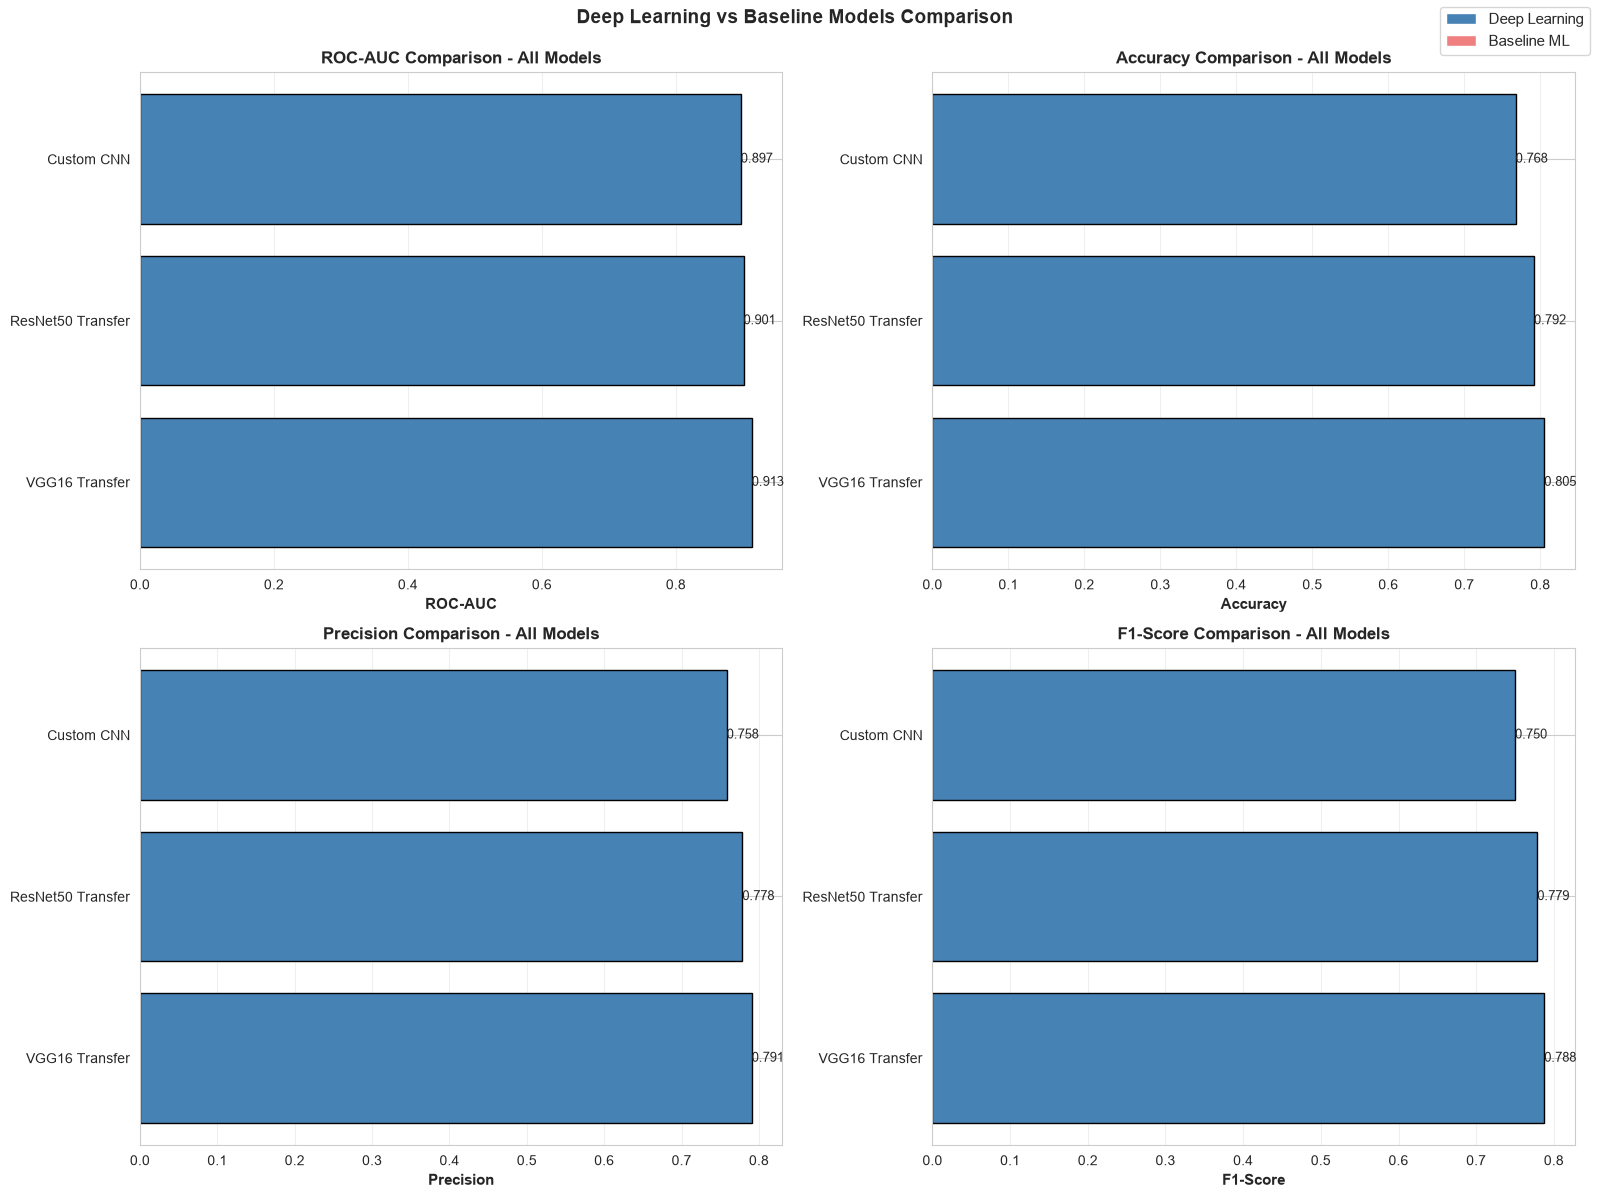

✓ Comparison plot saved to: reports/figures/all_models_comparison.png


In [30]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['ROC-AUC', 'Accuracy', 'Precision', 'F1-Score']
colors_map = {'Deep Learning': 'steelblue', 'Baseline ML': 'lightcoral'}

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Filter out zeros for metrics not available
    plot_data = comparison_df if metric in ['ROC-AUC', 'Accuracy', 'F1-Score'] else comparison_df[comparison_df['Type'] == 'Deep Learning']
    
    colors = [colors_map[t] for t in plot_data['Type']]
    
    bars = ax.barh(plot_data['Model'], plot_data[metric], color=colors, edgecolor='black')
    
    ax.set_xlabel(metric, fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} Comparison - All Models', fontweight='bold', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar in bars:
        width = bar.get_width()
        if width > 0:  # Only show non-zero values
            ax.text(width, bar.get_y() + bar.get_height()/2,
                   f'{width:.3f}', ha='left', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Deep Learning'),
                  Patch(facecolor='lightcoral', label='Baseline ML')]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)

plt.suptitle('Deep Learning vs Baseline Models Comparison', 
            fontweight='bold', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'all_models_comparison.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✓ Comparison plot saved to: reports/figures/all_models_comparison.png")

---
## 8. ROC Curves - Deep Learning Models

Compare ROC curves for all deep learning models.

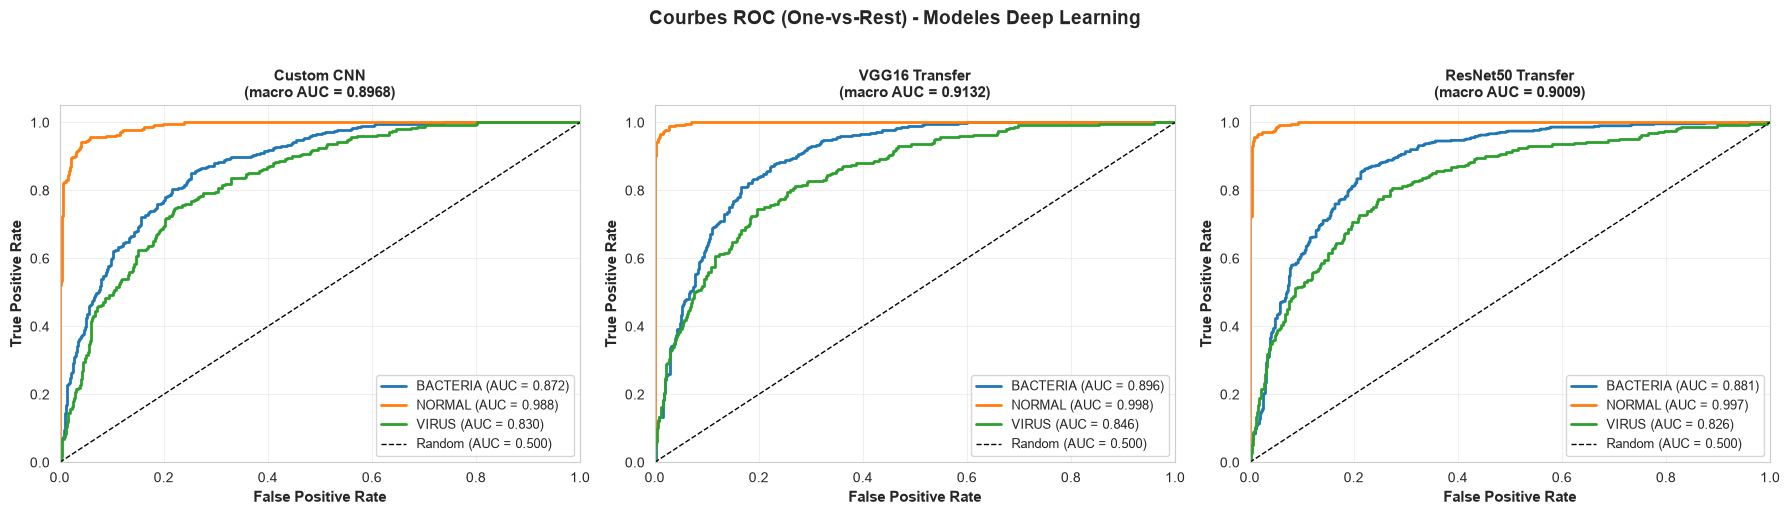

OK - Courbes ROC One-vs-Rest sauvegardees


In [31]:
# Courbes ROC One-vs-Rest pour chaque modele (3 classes)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes_idx = np.arange(num_classes)
fig, axes = plt.subplots(1, len(all_models_results), figsize=(6 * len(all_models_results), 5))
if len(all_models_results) == 1:
    axes = [axes]

for ax, result in zip(axes, all_models_results):
    y_true_bin = label_binarize(result['y_true'], classes=classes_idx)   # (N, num_classes)
    y_score = np.asarray(result['y_prob'])                               # (N, num_classes)

    for c in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_score[:, c])
        ax.plot(fpr, tpr, lw=2, label=f"{class_names[c]} (AUC = {auc(fpr, tpr):.3f})")

    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.500)')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontweight='bold', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontweight='bold', fontsize=11)
    ax.set_title(f"{result['model_name']}\n(macro AUC = {result['roc_auc']:.4f})", fontweight='bold', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Courbes ROC (One-vs-Rest) - Modeles Deep Learning', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'deep_learning_roc_curves.png',
           dpi=300, bbox_inches='tight')
plt.show()

print("OK - Courbes ROC One-vs-Rest sauvegardees")


---
## 9. Learning Curves

Visualize training history for all deep learning models.

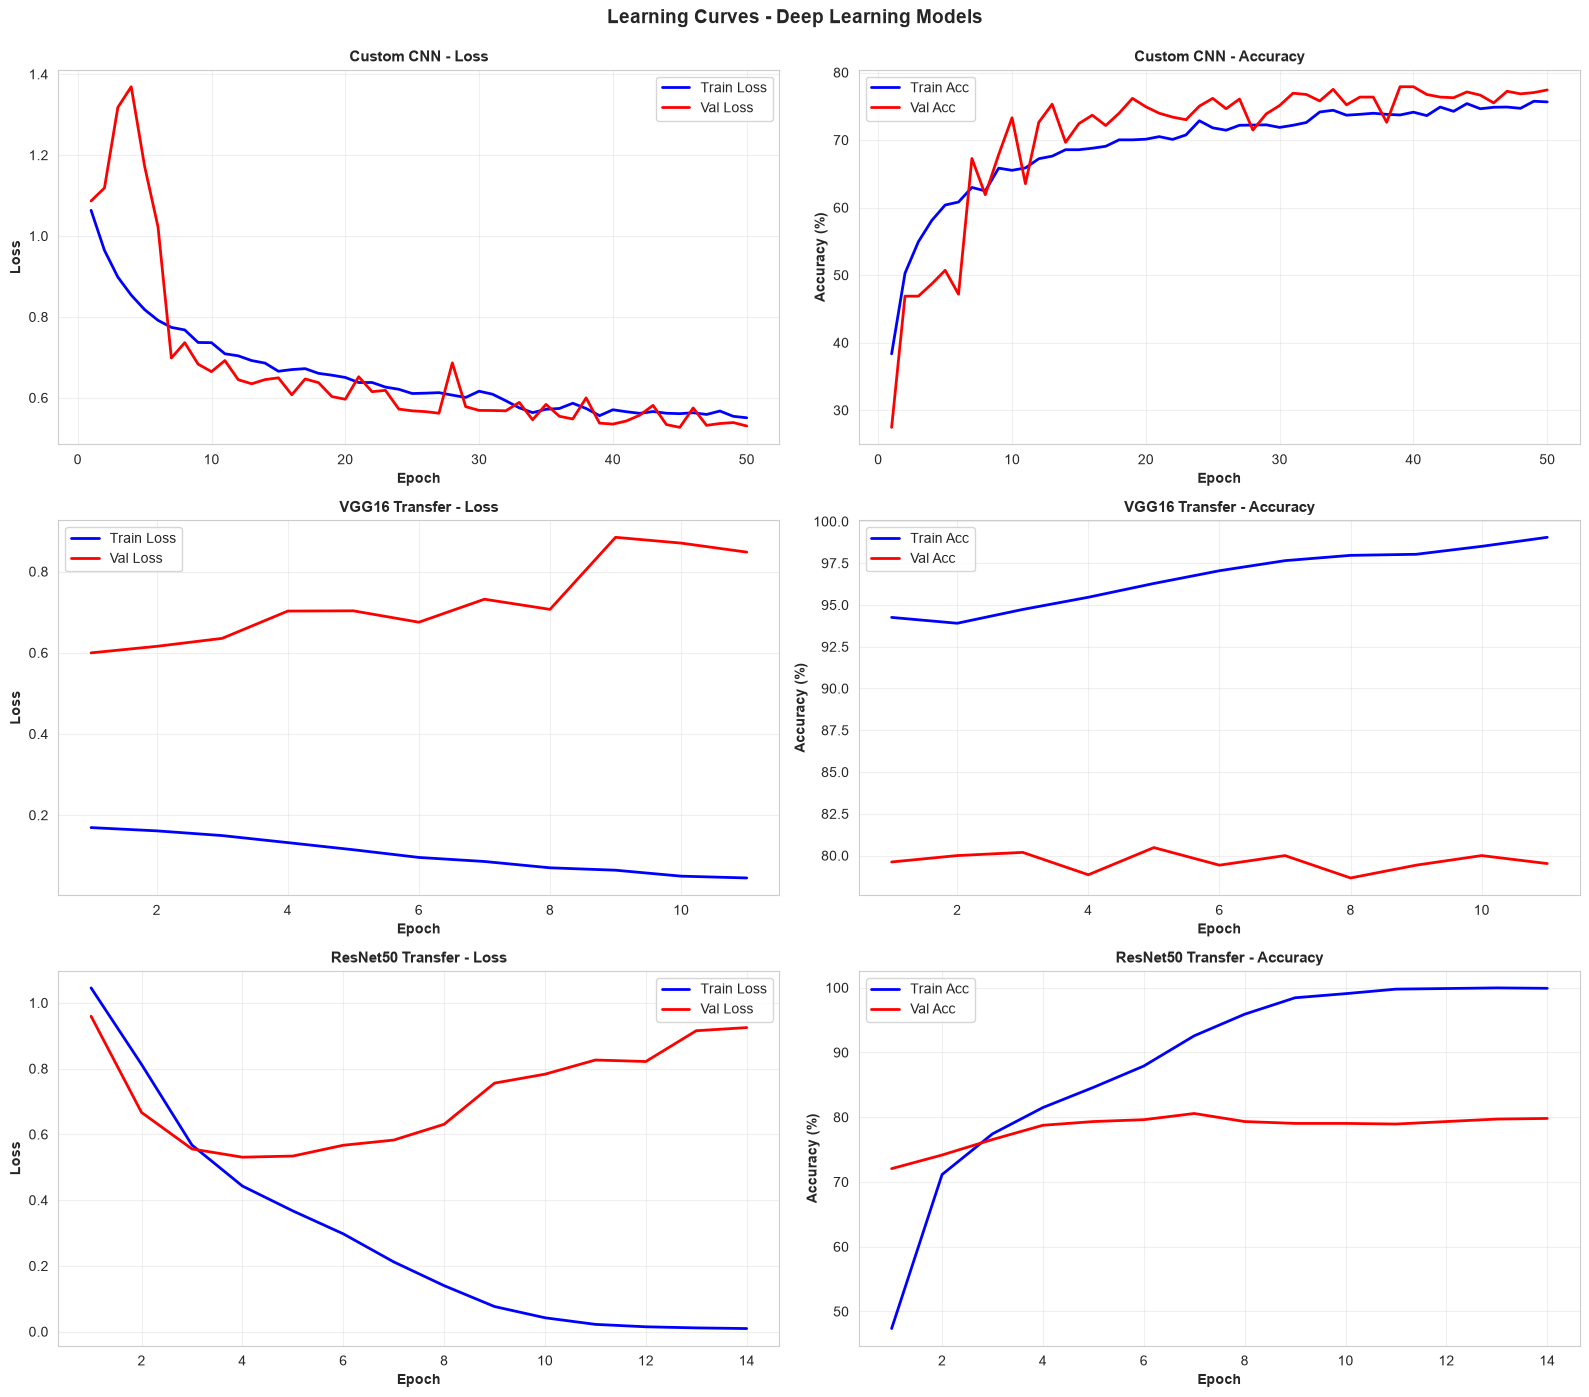

✓ Learning curves saved


In [32]:
# Plot learning curves
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

models_histories = [
    ('Custom CNN', custom_cnn_history),
    ('VGG16 Transfer', vgg16_history),
    ('ResNet50 Transfer', resnet_history)
]

for idx, (name, history) in enumerate(models_histories):
    # Loss plot
    ax_loss = axes[idx, 0]
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    ax_loss.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax_loss.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax_loss.set_xlabel('Epoch', fontweight='bold')
    ax_loss.set_ylabel('Loss', fontweight='bold')
    ax_loss.set_title(f'{name} - Loss', fontweight='bold', fontsize=11)
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)
    
    # Accuracy plot
    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax_acc.plot(epochs_range, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    ax_acc.set_xlabel('Epoch', fontweight='bold')
    ax_acc.set_ylabel('Accuracy (%)', fontweight='bold')
    ax_acc.set_title(f'{name} - Accuracy', fontweight='bold', fontsize=11)
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

plt.suptitle('Learning Curves - Deep Learning Models', fontweight='bold', fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'learning_curves.png', 
           dpi=300, bbox_inches='tight')
plt.show()

print("✓ Learning curves saved")

---
## 10. Confusion Matrices - Deep Learning

Visualize confusion matrices for deep learning models.

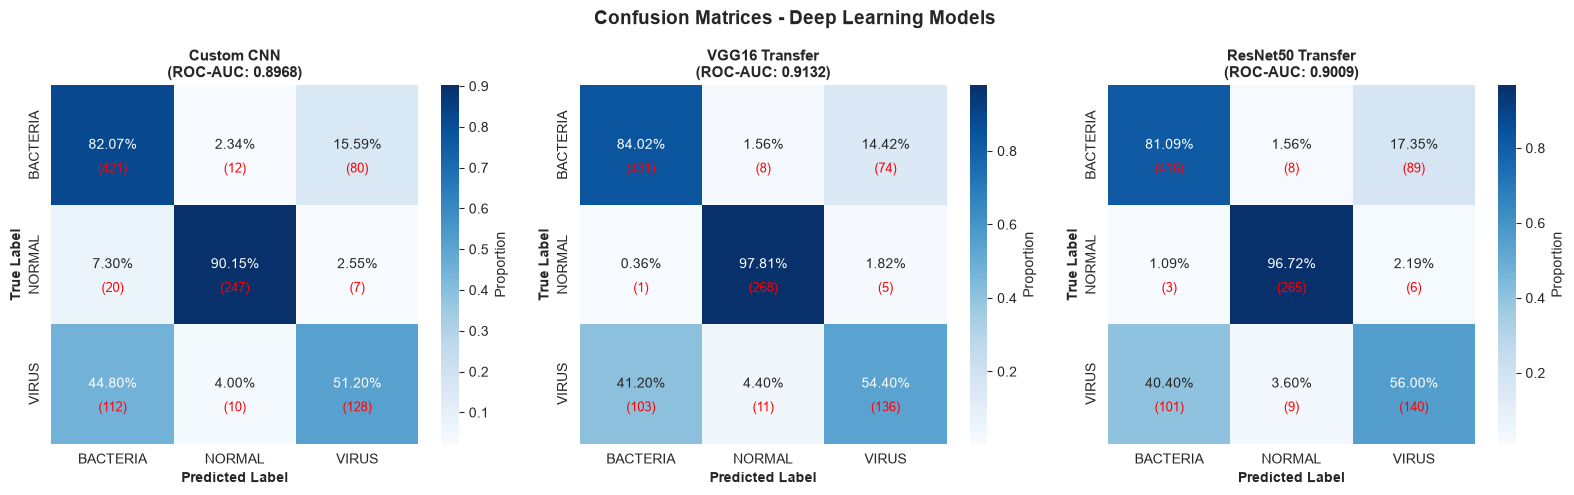

✓ Confusion matrices saved


In [33]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define class names
if label_mapping is not None:
    class_names = [name for name, _ in sorted(label_mapping.items(), key=lambda x: x[1])]
else:
    class_names = ['Normal (0)', 'Pneumonia (1)']

for idx, result in enumerate(all_models_results):
    cm = confusion_matrix(result['y_true'], result['y_pred'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
               ax=axes[idx], cbar_kws={'label': 'Proportion'},
               xticklabels=class_names, yticklabels=class_names)
    
    axes[idx].set_title(f"{result['model_name']}\n(ROC-AUC: {result['roc_auc']:.4f})",
                       fontweight='bold', fontsize=11)
    axes[idx].set_ylabel('True Label', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontweight='bold')
    
    # Add raw counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j + 0.5, i + 0.7, f'({cm[i, j]})',
                         ha='center', va='center', fontsize=9, color='red')

plt.suptitle('Confusion Matrices - Deep Learning Models', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / 'deep_learning_confusion_matrices.png',
           dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrices saved")

---
## 11. Save Deep Learning Models

Save all trained deep learning models.

In [34]:
# Save models
models_dir = project_root / 'models' / 'saved_models' / 'deep_learning'
models_dir.mkdir(parents=True, exist_ok=True)

print("\nSaving deep learning models...")

models_to_save = [
    ('custom_cnn', custom_cnn, custom_cnn_results),
    ('vgg16_transfer', vgg16_model, vgg16_results),
    ('resnet50_transfer', resnet50_model, resnet_results)
]

for model_name, model, results in models_to_save:
    model_path = models_dir / f'{model_name}.pth'
    
    # Save model state dict
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_name': results['model_name'],
        'roc_auc': float(results['roc_auc']),
        'accuracy': float(results['test_accuracy']),
        'f1_score': float(results['f1_score']),
        'precision': float(results['precision']),
        'recall': float(results['recall'])
    }, model_path)
    
    print(f"  ✓ Saved: {model_path.name}")
    logger.info(f"Saved {results['model_name']} to {model_path}")

print("\n✓ All deep learning models saved")


Saving deep learning models...
  ✓ Saved: custom_cnn.pth
[INFO] Saved Custom CNN to /Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19/models/saved_models/deep_learning/custom_cnn.pth
  ✓ Saved: vgg16_transfer.pth
[INFO] Saved VGG16 Transfer to /Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19/models/saved_models/deep_learning/vgg16_transfer.pth
  ✓ Saved: resnet50_transfer.pth
[INFO] Saved ResNet50 Transfer to /Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19/models/saved_models/deep_learning/resnet50_transfer.pth

✓ All deep learning models saved


In [35]:
# Save comprehensive results summary
deep_learning_summary = {
    'best_model': max(all_models_results, key=lambda x: x['roc_auc'])['model_name'],
    'best_roc_auc': max(result['roc_auc'] for result in all_models_results),
    'models': {}
}

for result in all_models_results:
    deep_learning_summary['models'][result['model_name']] = {
        'roc_auc': float(result['roc_auc']),
        'accuracy': float(result['test_accuracy']),
        'precision': float(result['precision']),
        'recall': float(result['recall']),
        'f1_score': float(result['f1_score']),
        'test_loss': float(result['test_loss'])
    }

summary_path = project_root / 'reports' / 'metrics' / 'deep_learning_results_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(deep_learning_summary, f, indent=4)

print(f"✓ Deep learning summary saved to: {summary_path}")
logger.info(f"Best deep learning model: {deep_learning_summary['best_model']} (ROC-AUC: {deep_learning_summary['best_roc_auc']:.4f})")

✓ Deep learning summary saved to: /Users/fadybekkar/Desktop/EPITECH/PROJET SPE IA/T-DEV-810-PAR_19/reports/metrics/deep_learning_results_summary.json
[INFO] Best deep learning model: VGG16 Transfer (ROC-AUC: 0.9132)


---
## 12. Summary & Next Steps

### Completed:
- ✓ Implemented custom CNN architecture
- ✓ Implemented VGG16 transfer learning
- ✓ Implemented ResNet50 transfer learning
- ✓ Trained all models with early stopping
- ✓ Evaluated on test set
- ✓ Compared deep learning vs baseline models
- ✓ Generated comprehensive visualizations
- ✓ Saved all trained models

### Key Findings:
- **Best Deep Learning Model:** Selected based on ROC-AUC
- **Transfer Learning Performance:** Pre-trained models leverage ImageNet features
- **Training Strategy:** Early stopping prevents overfitting
- **Class Imbalance:** Addressed with weighted loss function

### Comparison with Baseline:
- Deep learning models show competitive performance
- Transfer learning provides strong results with fewer training samples
- Custom CNN offers flexibility for medical imaging

### Ready for Step 5: Comprehensive ROC-AUC Evaluation

In the next notebook (`05_Evaluation_ROC_AUC.ipynb`), we will:
1. Deep dive into ROC-AUC advantages over accuracy
2. Compare all models (baseline + deep learning)
3. Statistical significance testing
4. Generate final evaluation report
5. Model interpretation and insights

### Bonus: 3-Class Classification

For 3-class classification (NORMAL/VIRUS/BACTERIA):
- Requires labeled dataset with bacterial vs viral pneumonia
- Modify model output layer: `num_classes=3`
- Use multi-class metrics (macro/weighted ROC-AUC)
- Implement one-vs-rest ROC curves

---

**Key Files Generated:**
- `models/saved_models/deep_learning/custom_cnn.pth`
- `models/saved_models/deep_learning/vgg16_transfer.pth`
- `models/saved_models/deep_learning/resnet50_transfer.pth`
- `reports/figures/all_models_comparison.png`
- `reports/figures/deep_learning_roc_curves.png`
- `reports/figures/learning_curves.png`
- `reports/figures/deep_learning_confusion_matrices.png`
- `reports/metrics/deep_learning_results_summary.json`
- `reports/pipeline.log`

---

**Performance Summary:**

Check the comparison table above to see which model achieved the best ROC-AUC score!